<a href="https://colab.research.google.com/github/JAPIA7/Analysis-of-large-dataset/blob/main/Socialmedia_trend_analysis_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MILESTONE 1**

1.1 DATA CHARACTERIZATION

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
print(f'Rows: {len(df)}, Columns: {len(df.columns)}')
print(df.dtypes)
print(df.describe())
print(df.isnull().sum())   # check missing values
print(df['Platform'].value_counts())
print(df['Region'].value_counts())
print(df['Engagement_Level'].value_counts())


Rows: 5000, Columns: 11
Post_ID             object
Post_Date           object
Platform            object
Hashtag             object
Content_Type        object
Region              object
Views                int64
Likes                int64
Shares               int64
Comments             int64
Engagement_Level    object
dtype: object
              Views          Likes        Shares      Comments
count  5.000000e+03    5000.000000   5000.000000   5000.000000
mean   2.494066e+06  251475.029800  50519.562000  24888.393800
std    1.459490e+06  144349.583384  29066.362671  14284.504319
min    1.266000e+03     490.000000     52.000000     18.000000
25%    1.186207e+06  126892.250000  25029.000000  12305.250000
50%    2.497373e+06  249443.000000  50839.500000  25004.000000
75%    3.759781e+06  373970.750000  75774.250000  37072.750000
max    4.999430e+06  499922.000000  99978.000000  49993.000000
Post_ID             0
Post_Date           0
Platform            0
Hashtag             0
Content_Ty

1.12 CHARACTIRIZE VOLUME

In [2]:
df['Post_Date'] = pd.to_datetime(df['Post_Date'])
daily_counts = df.groupby('Post_Date').size()
print(f'Avg posts/day: {daily_counts.mean():.0f}')
print(f'Peak posts/day: {daily_counts.max()}')


Avg posts/day: 7
Peak posts/day: 17


1.2 DATA SOURCING AND INGESTION

In [3]:
CHUNK_SIZE = 1000  # process 1000 rows at a time
chunks = []
for chunk in pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv', chunksize=CHUNK_SIZE):
    chunk['Post_Date'] = pd.to_datetime(chunk['Post_Date'])
    chunk['Engagement_Rate'] = (chunk['Likes'] + chunk['Shares'] + chunk['Comments']) / chunk['Views']
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
print(f'Ingested {len(df)} records successfully')


Ingested 5000 records successfully


1.3 Complexity & Scalability Analysis

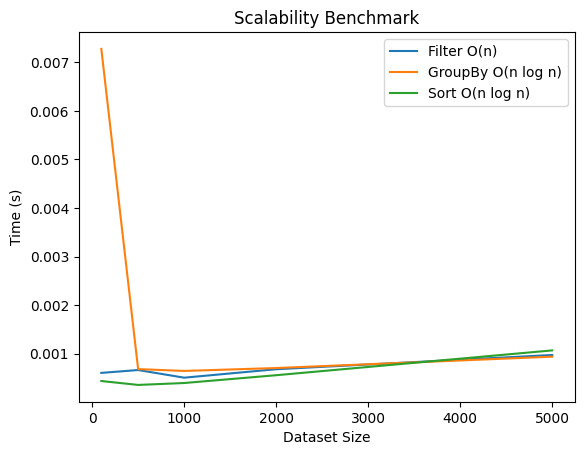

In [4]:
import time
import matplotlib.pyplot as plt

df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
sizes = [100, 500, 1000, 2000, 5000]
times_filter, times_group, times_sort = [], [], []

for n in sizes:
    sample = df.sample(n=n, random_state=42)
    t0 = time.perf_counter()
    _ = sample[sample['Platform'] == 'TikTok']
    times_filter.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    _ = sample.groupby('Platform')['Views'].mean()
    times_group.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    _ = sample.sort_values('Views')
    times_sort.append(time.perf_counter() - t0)

plt.plot(sizes, times_filter, label='Filter O(n)')
plt.plot(sizes, times_group, label='GroupBy O(n log n)')
plt.plot(sizes, times_sort, label='Sort O(n log n)')
plt.xlabel('Dataset Size'); plt.ylabel('Time (s)')
plt.title('Scalability Benchmark'); plt.legend(); plt.savefig('scalability.png')


1.5 INITIAL BATCH DATA PIPELINE

In [5]:
import os

def ingest(path):
    return pd.read_csv(path)

def clean(df):
    df = df.dropna()
    df['Post_Date'] = pd.to_datetime(df['Post_Date'])
    df['Views'] = df['Views'].clip(lower=0)
    return df

def transform(df):
    df['Engagement_Rate'] = (df['Likes'] + df['Shares'] + df['Comments']) / df['Views'].replace(0, 1)
    df['Month'] = df['Post_Date'].dt.month
    df['Year'] = df['Post_Date'].dt.year
    df['DayOfWeek'] = df['Post_Date'].dt.day_name()
    return df

def load(df, out_path):
    df.to_parquet(out_path, index=False)
    print(f'Saved {len(df)} records to {out_path}')

if __name__ == '__main__':
    df = ingest('Cleaned_Viral_Social_Media_Trends.csv')
    df = clean(df)
    df = transform(df)
    load(df, 'processed_trends.parquet')


Saved 5000 records to processed_trends.parquet


# **MILESTONE 2**

DISTRIBUTED DATA PROCESSING

2.1 Data Partitioning & Sharding

In [6]:
df = pd.read_parquet('processed_trends.parquet')

# Partition by Platform
os.makedirs('partitions', exist_ok=True)
for platform, partition in df.groupby('Platform'):
    path = f'partitions/platform={platform}/data.parquet'
    os.makedirs(os.path.dirname(path), exist_ok=True)
    partition.to_parquet(path, index=False)
    print(f'{platform}: {len(partition)} records -> {path}')


Instagram: 1212 records -> partitions/platform=Instagram/data.parquet
TikTok: 1260 records -> partitions/platform=TikTok/data.parquet
Twitter: 1204 records -> partitions/platform=Twitter/data.parquet
YouTube: 1324 records -> partitions/platform=YouTube/data.parquet


In [7]:
def hash_shard(df, n_shards=4, key='Post_ID'):
    df['shard'] = df[key].apply(lambda x: hash(x) % n_shards)
    for shard_id, shard in df.groupby('shard'):
        shard.to_parquet(f'partitions/shard_{shard_id}.parquet', index=False)
        print(f'Shard {shard_id}: {len(shard)} records')

hash_shard(df)


Shard 0: 1253 records
Shard 1: 1289 records
Shard 2: 1211 records
Shard 3: 1247 records


2.2 Batch Processing (MapReduce Concepts)

In [8]:
from collections import defaultdict

df = pd.read_parquet('processed_trends.parquet')
records = df.to_dict('records')

# MAP: emit (platform, engagement_rate) for each record
def mapper(record):
    return (record['Platform'], record['Engagement_Rate'])

mapped = [mapper(r) for r in records]

# SHUFFLE: group by key
shuffled = defaultdict(list)
for key, value in mapped:
    shuffled[key].append(value)

# REDUCE: average per platform
def reducer(key, values):
    return (key, sum(values) / len(values))

results = dict(reducer(k, v) for k, v in shuffled.items())
print('Average Engagement Rate by Platform:')
for p, r in sorted(results.items(), key=lambda x: -x[1]):
    print(f'  {p}: {r:.4f}')


Average Engagement Rate by Platform:
  Instagram: 0.6621
  TikTok: 0.6387
  YouTube: 0.5064
  Twitter: 0.4654


parallel batch processing

In [9]:
from multiprocessing import Pool

def process_partition(path):
    chunk = pd.read_parquet(path)
    return {
        'platform': chunk['Platform'].iloc[0],
        'total_views': chunk['Views'].sum(),
        'avg_engagement': chunk['Engagement_Rate'].mean(),
        'top_hashtag': chunk['Hashtag'].value_counts().idxmax()
    }

import glob
paths = glob.glob('partitions/platform=*/data.parquet')
with Pool(4) as pool:
    results = pool.map(process_partition, paths)

print(pd.DataFrame(results))


    platform  total_views  avg_engagement top_hashtag
0     TikTok   3168919406        0.638711     #Comedy
1    Twitter   3017229522        0.465425     #Comedy
2    YouTube   3370438480        0.506368  #Challenge
3  Instagram   2913744812        0.662058    #Fitness


2.3 Distributed Storage (HDFS Equivalent)

In [10]:
import pyarrow as pa
import pyarrow.parquet as pq

df = pd.read_parquet('processed_trends.parquet')
table = pa.Table.from_pandas(df)

pq.write_to_dataset(
    table,
    root_path='hdfs_sim/',
    partition_cols=['Platform', 'Year']
)
print('Partitioned Parquet written to hdfs_sim/')


Partitioned Parquet written to hdfs_sim/


In [11]:
import glob
files = glob.glob('hdfs_sim/**/*.parquet', recursive=True)
for f in sorted(files):
    print(f)


hdfs_sim/Platform=Instagram/Year=2022/a7bb45efeb704772ab1487f8864b6d98-0.parquet
hdfs_sim/Platform=Instagram/Year=2023/a7bb45efeb704772ab1487f8864b6d98-0.parquet
hdfs_sim/Platform=TikTok/Year=2022/a7bb45efeb704772ab1487f8864b6d98-0.parquet
hdfs_sim/Platform=TikTok/Year=2023/a7bb45efeb704772ab1487f8864b6d98-0.parquet
hdfs_sim/Platform=Twitter/Year=2022/a7bb45efeb704772ab1487f8864b6d98-0.parquet
hdfs_sim/Platform=Twitter/Year=2023/a7bb45efeb704772ab1487f8864b6d98-0.parquet
hdfs_sim/Platform=YouTube/Year=2022/a7bb45efeb704772ab1487f8864b6d98-0.parquet
hdfs_sim/Platform=YouTube/Year=2023/a7bb45efeb704772ab1487f8864b6d98-0.parquet


In [12]:
dataset = pq.ParquetDataset('hdfs_sim/', filters=[('Platform', '=', 'TikTok'), ('Year', '=', 2023)])
tiktok_2023 = dataset.read().to_pandas()
print(f'TikTok 2023 records: {len(tiktok_2023)}')


TikTok 2023 records: 581


2.4 Fault Tolerance & Replication

In [13]:
import json

CHECKPOINT_FILE = 'checkpoint.json'

def load_checkpoint():
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE) as f:
            return json.load(f)
    return {'last_chunk': 0}

def save_checkpoint(state):
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(state, f)

checkpoint = load_checkpoint()
start_chunk = checkpoint['last_chunk']

for i, chunk in enumerate(pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv', chunksize=500)):
    if i < start_chunk:
        continue  # skip already-processed chunks
    # ... process chunk ...
    save_checkpoint({'last_chunk': i + 1})
    print(f'Processed chunk {i}')


Processed chunk 0
Processed chunk 1
Processed chunk 2
Processed chunk 3
Processed chunk 4
Processed chunk 5
Processed chunk 6
Processed chunk 7
Processed chunk 8
Processed chunk 9


simulate file replication

In [14]:
import shutil

df = pd.read_parquet('processed_trends.parquet')
REPLICATION = 3

for platform, part in df.groupby('Platform'):
    for replica in range(REPLICATION):
        path = f'replicated/node_{replica}/platform={platform}/data.parquet'
        os.makedirs(os.path.dirname(path), exist_ok=True)
        part.to_parquet(path, index=False)

print('Replication complete — 3 copies per partition')


Replication complete — 3 copies per partition


2.5 Job Scheduling & Execution Pipelines

In [15]:
from functools import wraps

dag = {}

def task(name, depends_on=[]):
    def decorator(func):
        dag[name] = {'fn': func, 'depends_on': depends_on}
        return func
    return decorator

@task('ingest')
def ingest(): return pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')

@task('clean', depends_on=['ingest'])
def clean(df):
    df['Post_Date'] = pd.to_datetime(df['Post_Date'])
    return df.dropna()

@task('transform', depends_on=['clean'])
def transform(df):
    df['Engagement_Rate'] = (df['Likes']+df['Shares']+df['Comments'])/df['Views'].replace(0,1)
    return df

@task('aggregate', depends_on=['transform'])
def aggregate(df):
    return df.groupby('Platform')[['Views','Engagement_Rate']].mean()

# Run DAG in topological order
results = {}
for name, info in dag.items():
    print(f'Running task: {name}')
    t0 = time.time()
    args = [results[d] for d in info['depends_on']]
    results[name] = info['fn'](*args)
    print(f'  Done in {time.time()-t0:.3f}s')

print(results['aggregate'])


Running task: ingest
  Done in 0.020s
Running task: clean
  Done in 0.006s
Running task: transform
  Done in 0.001s
Running task: aggregate
  Done in 0.004s
                  Views  Engagement_Rate
Platform                                
Instagram  2.404080e+06         0.662058
TikTok     2.515015e+06         0.638711
Twitter    2.506005e+06         0.465425
YouTube    2.545648e+06         0.506368


# **MILESTONE 3**

3.1 Streaming Ingestion (Kafka Simulation)

In [16]:
from queue import Queue
import threading

df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')

kafka_topic = Queue(maxsize=100)  # bounded buffer

def kafka_producer(df, topic, delay=0.01):
    for _, row in df.iterrows():
        message = row.to_dict()
        message['timestamp'] = time.time()
        topic.put(message)
        time.sleep(delay)  # simulate arrival rate
    topic.put(None)  # sentinel

producer_thread = threading.Thread(target=kafka_producer, args=(df, kafka_topic))
producer_thread.start()


In [17]:
def kafka_consumer(topic, process_fn):
    processed = 0
    while True:
        message = topic.get()
        if message is None:
            break
        process_fn(message)
        processed += 1
    print(f'Consumer processed {processed} messages')

def process_post(msg):
    rate = (msg['Likes'] + msg['Shares'] + msg['Comments']) / max(msg['Views'], 1)
    if rate > 0.15:
        print(f"VIRAL ALERT: {msg['Post_ID']} ({msg['Platform']}) rate={rate:.3f}")

kafka_consumer(kafka_topic, process_post)


VIRAL ALERT: Post_4 (YouTube) rate=0.191
VIRAL ALERT: Post_5 (TikTok) rate=3.813
VIRAL ALERT: Post_6 (Instagram) rate=0.204
VIRAL ALERT: Post_7 (YouTube) rate=0.342
VIRAL ALERT: Post_8 (YouTube) rate=0.192
VIRAL ALERT: Post_9 (Twitter) rate=0.287
VIRAL ALERT: Post_14 (YouTube) rate=0.238
VIRAL ALERT: Post_15 (Twitter) rate=0.179
VIRAL ALERT: Post_17 (Twitter) rate=0.862
VIRAL ALERT: Post_21 (Twitter) rate=26.660
VIRAL ALERT: Post_23 (YouTube) rate=0.428
VIRAL ALERT: Post_25 (YouTube) rate=0.788
VIRAL ALERT: Post_28 (YouTube) rate=0.217
VIRAL ALERT: Post_31 (Instagram) rate=0.190
VIRAL ALERT: Post_35 (YouTube) rate=0.494
VIRAL ALERT: Post_37 (Instagram) rate=5.270
VIRAL ALERT: Post_42 (YouTube) rate=0.460
VIRAL ALERT: Post_46 (Instagram) rate=1.277
VIRAL ALERT: Post_47 (Instagram) rate=0.259
VIRAL ALERT: Post_50 (Instagram) rate=0.177
VIRAL ALERT: Post_51 (YouTube) rate=0.155
VIRAL ALERT: Post_53 (YouTube) rate=0.439
VIRAL ALERT: Post_54 (Twitter) rate=1.073
VIRAL ALERT: Post_58 (Twitte

3.2 Event-Driven Architecture

In [18]:
from collections import defaultdict

class EventBus:
    def __init__(self):
        self.subscribers = defaultdict(list)

    def subscribe(self, event_type, handler):
        self.subscribers[event_type].append(handler)

    def publish(self, event_type, event):
        for handler in self.subscribers[event_type]:
            handler(event)

bus = EventBus()

# Three independent handlers for the same event
trend_cache = defaultdict(int)

def trend_detector(event):
    trend_cache[event['Hashtag']] += event['Views']

# Register the handlers correctly
bus.subscribe('new_post', trend_detector)
bus.subscribe('new_post', lambda e: trend_cache.__setitem__(e['Hashtag'], trend_cache[e['Hashtag']] + e['Views']))
bus.subscribe('new_post', lambda e: print(f"Archived: {e['Post_ID']}") if e['Engagement_Level'] == 'High' else None)

# Emit events from CSV
df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
for _, row in df.head(100).iterrows():
    bus.publish('new_post', row.to_dict())

print('Top hashtags by views:', sorted(trend_cache.items(), key=lambda x: -x[1])[:5])

Archived: Post_1
Archived: Post_8
Archived: Post_11
Archived: Post_13
Archived: Post_14
Archived: Post_15
Archived: Post_24
Archived: Post_25
Archived: Post_36
Archived: Post_39
Archived: Post_41
Archived: Post_42
Archived: Post_46
Archived: Post_49
Archived: Post_55
Archived: Post_59
Archived: Post_64
Archived: Post_66
Archived: Post_67
Archived: Post_68
Archived: Post_69
Archived: Post_74
Archived: Post_76
Archived: Post_80
Archived: Post_84
Archived: Post_86
Archived: Post_87
Archived: Post_89
Archived: Post_91
Archived: Post_94
Archived: Post_96
Archived: Post_99
Top hashtags by views: [('#Gaming', 78972944), ('#Comedy', 74942614), ('#Education', 63944528), ('#Dance', 53525046), ('#Challenge', 52933796)]


3.3 Real-Time Analytics Pipeline

In [19]:
df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
df['Post_Date'] = pd.to_datetime(df['Post_Date'])
df = df.sort_values('Post_Date')

# Tumbling daily window
daily_stats = df.resample('D', on='Post_Date').agg(
    total_views=('Views', 'sum'),
    avg_engagement=('Engagement_Rate', 'mean') if 'Engagement_Rate' in df.columns else ('Views', 'count'),
    post_count=('Post_ID', 'count'),
    top_platform=('Platform', lambda x: x.value_counts().idxmax())
)
print(daily_stats.head(10))
daily_stats.to_parquet('daily_window_stats.parquet')


            total_views  avg_engagement  post_count top_platform
Post_Date                                                       
2022-01-01      8469206               4           4      YouTube
2022-01-02     11556983               6           6       TikTok
2022-01-03     13007956               5           5    Instagram
2022-01-04     15568302               6           6    Instagram
2022-01-05     16424773               6           6      YouTube
2022-01-06     24121315               9           9       TikTok
2022-01-07     20108222               8           8       TikTok
2022-01-08      2297212               3           3    Instagram
2022-01-09     18957665               8           8      Twitter
2022-01-10     11957104               7           7      YouTube


In [20]:
#7 day rolling window
# Weekly rolling views per hashtag
df_h = df.groupby(['Post_Date', 'Hashtag'])['Views'].sum().reset_index()
df_h = df_h.sort_values('Post_Date')
df_h['Rolling7d'] = df_h.groupby('Hashtag')['Views'].transform(lambda x: x.rolling(7, min_periods=1).sum())

# Find the top hashtag per day
top_daily = df_h.loc[df_h.groupby('Post_Date')['Rolling7d'].idxmax()]
print(top_daily.tail(10))


      Post_Date     Hashtag    Views   Rolling7d
3577 2023-12-21       #Tech  4153069  33805040.0
3579 2023-12-22      #Dance  3236693  36047546.0
3583 2023-12-23      #Dance  4291403  34613121.0
3589 2023-12-24      #Dance  2944616  32863672.0
3595 2023-12-25       #Tech  4397447  28640315.0
3597 2023-12-26  #Challenge  2291491  28683700.0
3606 2023-12-27      #Viral  8061786  34037864.0
3610 2023-12-28    #Fitness  5162389  28213337.0
3616 2023-12-29    #Fitness  4487563  29100355.0
3624 2023-12-30      #Viral  3746244  36133514.0


3.4 Approximate Algorithms

In [21]:
pip install pybloom-live

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.6/343.6 kB 9.2 MB/s eta 0:00:00
  Created wheel for pybloom-live: filename=pybloom_live-4.0.0-py3-none-any.whl size=9229 sha256=0d9bf7347ad338eb94b20c868b5433e65eed6bf120d107c29246a94a2dae699a
  Stored in directory: /root/.cache/pip/wheels/1d/5e/b8/19c04c108b0acd2ca53b85fcc09eeed323ecdfea0e36bd134e
Successfully built pybloom-live


In [22]:
from pybloom_live import BloomFilter

df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
bf = BloomFilter(capacity=10000, error_rate=0.01)

duplicates_caught = 0
for post_id in df['Post_ID']:
    if post_id in bf:
        duplicates_caught += 1
    else:
        bf.add(post_id)

print(f'Unique posts: {len(bf)}')
print(f'Duplicates detected: {duplicates_caught}')
print(f'Memory: ~{bf.num_bits // 8 / 1024:.1f} KB (vs exact set would need much more)')


Unique posts: 5000
Duplicates detected: 0
Memory: ~11.7 KB (vs exact set would need much more)


In [23]:
#estimating hashtag frequency
import hashlib
import numpy as np

class CountMinSketch:
    def __init__(self, width=1000, depth=5):
        self.width = width
        self.depth = depth
        self.table = np.zeros((depth, width), dtype=int)

    def _hashes(self, item):
        return [int(hashlib.md5(f'{i}{item}'.encode()).hexdigest(), 16) % self.width for i in range(self.depth)]

    def add(self, item, count=1):
        for i, h in enumerate(self._hashes(item)):
            self.table[i][h] += count

    def query(self, item):
        return min(self.table[i][h] for i, h in enumerate(self._hashes(item)))

cms = CountMinSketch()
for _, row in df.iterrows():
    cms.add(row['Hashtag'], row['Views'])

for tag in df['Hashtag'].unique():
    estimated = cms.query(tag)
    exact = df[df['Hashtag']==tag]['Views'].sum()
    print(f'{tag:15s} exact={exact:>10,}  estimated={estimated:>10,}  error={abs(estimated-exact)/exact*100:.1f}%')


#Challenge      exact=1,242,826,928  estimated=1,242,826,928  error=0.0%
#Education      exact=1,328,894,615  estimated=1,328,894,615  error=0.0%
#Dance          exact=1,213,891,935  estimated=1,213,891,935  error=0.0%
#Comedy         exact=1,237,321,563  estimated=1,237,321,563  error=0.0%
#Gaming         exact=1,197,834,795  estimated=1,197,834,795  error=0.0%
#Music          exact=1,266,398,079  estimated=1,266,398,079  error=0.0%
#Viral          exact=1,172,480,925  estimated=1,172,480,925  error=0.0%
#Fitness        exact=1,393,273,574  estimated=1,393,273,574  error=0.0%
#Tech           exact=1,235,543,295  estimated=1,235,543,295  error=0.0%
#Fashion        exact=1,181,866,511  estimated=1,181,866,511  error=0.0%


3.5 Batch vs Streaming Comparison

In [24]:
# BATCH
t0 = time.perf_counter()
batch_result = df.groupby('Platform')['Views'].sum()
batch_time = time.perf_counter() - t0

# STREAMING simulation
from collections import defaultdict
stream_agg = defaultdict(int)
t0 = time.perf_counter()
for _, row in df.iterrows():
    stream_agg[row['Platform']] += row['Views']
stream_time = time.perf_counter() - t0

print(f'Batch time:   {batch_time:.4f}s  (result available AFTER full scan)')
print(f'Stream time:  {stream_time:.4f}s  (result updated AFTER EACH record)')
print('Results match:', dict(batch_result) == dict(stream_agg))


Batch time:   0.0021s  (result available AFTER full scan)
Stream time:  0.2583s  (result updated AFTER EACH record)
Results match: True


# **MILESTONE 4**

4.1 Feature Engineering on Large Datasets

In [25]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
df['Post_Date'] = pd.to_datetime(df['Post_Date'])

# 1. Time-based features
df['DayOfWeek'] = df['Post_Date'].dt.dayofweek       # 0=Mon, 6=Sun
df['Month'] = df['Post_Date'].dt.month
df['Quarter'] = df['Post_Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# 2. Engagement features
df['Engagement_Rate'] = (df['Likes'] + df['Shares'] + df['Comments']) / df['Views'].replace(0, 1)
df['Like_Rate'] = df['Likes'] / df['Views'].replace(0, 1)
df['Share_Rate'] = df['Shares'] / df['Views'].replace(0, 1)
df['Comment_Rate'] = df['Comments'] / df['Views'].replace(0, 1)
df['Log_Views'] = np.log1p(df['Views'])

# 3. Encode categoricals
le = LabelEncoder()
for col in ['Platform', 'Hashtag', 'Content_Type', 'Region']:
    df[f'{col}_enc'] = le.fit_transform(df[col])

# 4. One-hot encode Platform (for linear models)
df = pd.get_dummies(df, columns=['Platform'], prefix='plat', drop_first=True)

print('Feature columns:', [c for c in df.columns if c not in ['Post_ID', 'Post_Date']])
print(df.shape)


Feature columns: ['Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level', 'DayOfWeek', 'Month', 'Quarter', 'IsWeekend', 'Engagement_Rate', 'Like_Rate', 'Share_Rate', 'Comment_Rate', 'Log_Views', 'Platform_enc', 'Hashtag_enc', 'Content_Type_enc', 'Region_enc', 'plat_TikTok', 'plat_Twitter', 'plat_YouTube']
(5000, 26)


Identify the most predictive features using correlation analysis

In [26]:
target = df['Engagement_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})
num_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[num_cols].corrwith(target).abs().sort_values(ascending=False)
print('Top features correlated with Engagement_Level:')
print(correlations.head(10))


Top features correlated with Engagement_Level:
Views               0.016788
Comments            0.016758
Content_Type_enc    0.013941
Comment_Rate        0.013211
Platform_enc        0.011987
Like_Rate           0.009322
Region_enc          0.008825
Engagement_Rate     0.008818
IsWeekend           0.008695
Likes               0.007809
dtype: float64


4.2 Model Training

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

feature_cols = ['Log_Views', 'Like_Rate', 'Share_Rate', 'Comment_Rate',
                'DayOfWeek', 'Month', 'IsWeekend', 'Quarter',
                'Hashtag_enc', 'Content_Type_enc', 'Region_enc']

X = df[feature_cols].fillna(0)
y = LabelEncoder().fit_transform(df['Engagement_Level'])  # Low=0, Med=1, High=2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')


Train: 4000, Test: 1000


In [28]:
pip install xgboost

Train a Gradient Boosting model (XGBoost)

In [29]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                    use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)


[0]	validation_0-mlogloss:1.09801
[50]	validation_0-mlogloss:1.11344


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:21:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-mlogloss:1.12668
[150]	validation_0-mlogloss:1.14836
[199]	validation_0-mlogloss:1.16849


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Train a Neural Network (scikit-learn MLPClassifier)

In [30]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                    max_iter=200, random_state=42, early_stopping=True)
mlp.fit(X_train_s, y_train)


MLPClassifier(early_stopping=True, hidden_layer_sizes=(128, 64, 32),
              random_state=42)

4.3 Distributed/parallel training

In [ ]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

t0 = time.time()
grid_search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=2  # n_jobs=-1 = all cores
)
grid_search.fit(X_train, y_train)
print(f'Best params: {grid_search.best_params_}')
print(f'Grid search time: {time.time()-t0:.1f}s')


Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [ ]:
#Train on data partitions in parallel to simulate distributed data parallelism
from multiprocessing import Pool
from xgboost import XGBClassifier
import numpy as np

def train_on_partition(args):
    X_part, y_part = args
    model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss')
    model.fit(X_part, y_part)
    return model.feature_importances_

# Split training data into 4 partitions
partitions = [(X_train.iloc[i::4], y_train[i::4]) for i in range(4)]

with Pool(4) as pool:
    importances = pool.map(train_on_partition, partitions)

# Average importances across partitions (simulates parameter averaging)
avg_importance = np.mean(importances, axis=0)
print('Averaged feature importances:', dict(zip(feature_cols, avg_importance.round(3))))


4.4 Model Validation & Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

models = {'XGBoost': (xgb, X_test), 'MLP': (mlp, X_test_s)}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['High', 'Low', 'Medium']))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=['High','Low','Med'], yticklabels=['High','Low','Med'])
    plt.title(f'{name} Confusion Matrix')
    plt.savefig(f'{name}_confusion_matrix.png', dpi=150, bbox_inches='tight')


In [ ]:
#run 5 fold cross vaidation
from sklearn.model_selection import cross_val_score

cv_xgb = cross_val_score(xgb, X, y, cv=5, scoring='f1_macro', n_jobs=-1)
print(f'XGBoost CV F1-macro: {cv_xgb.mean():.3f} +/- {cv_xgb.std():.3f}')


FEATURE IMPORTANCE

In [ ]:
pip install shap

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Initialize the explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Global summary plot
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.close()

# Local explanation for one prediction (Class 0)
sample_idx = 0
class_idx = 0

# Handle the shape based on whether shap_values is a list (multi-class) or array
if isinstance(shap_values, list):
    current_shap_values = shap_values[class_idx][sample_idx]
    expected_val = explainer.expected_value[class_idx]
else:
    # For some versions/configs, it might be a 3D array [samples, features, classes]
    current_shap_values = shap_values[sample_idx, :, class_idx]
    expected_val = explainer.expected_value[class_idx]

shap.force_plot(
    expected_val,
    current_shap_values,
    X_test.iloc[sample_idx].values,
    feature_names=feature_cols,
    matplotlib=True,
    show=False
)
plt.savefig('shap_force_plot.png', dpi=150, bbox_inches='tight')

# **MILESTONE 5**

SYSTEM OPTIMIZATION AND DEPLOYMENT

5.1 Model Deployment Pipeline

In [ ]:
import joblib
import os
import json
import time
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Save trained models and preprocessing artefacts to disk
os.makedirs('deployed_model', exist_ok=True)

# Re-use the objects already in memory from Milestone 4
# (xgb, mlp, scaler, feature_cols, le)
joblib.dump(xgb,   'deployed_model/xgb_model.pkl')
joblib.dump(mlp,   'deployed_model/mlp_model.pkl')
joblib.dump(scaler,'deployed_model/scaler.pkl')

model_meta = {
    'feature_cols':   feature_cols,
    'classes':        ['High', 'Low', 'Medium'],
    'trained_at':     time.strftime('%Y-%m-%d %H:%M:%S'),
    'xgb_n_estimators': int(xgb.n_estimators),
    'mlp_layers':     list(mlp.hidden_layer_sizes)
}
with open('deployed_model/metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('Saved to deployed_model/')
for fname in os.listdir('deployed_model'):
    size_kb = os.path.getsize(f'deployed_model/{fname}') / 1024
    print(f'  {fname}  ({size_kb:.1f} KB)')


In [ ]:
# Prediction service - mirrors how a REST endpoint would work

def load_model_service(model_dir='deployed_model'):
    model  = joblib.load(f'{model_dir}/xgb_model.pkl')
    sc     = joblib.load(f'{model_dir}/scaler.pkl')
    with open(f'{model_dir}/metadata.json') as f:
        meta = json.load(f)
    return model, sc, meta

def predict_engagement(raw_post: dict, model, scaler, meta) -> dict:
    """Accept a single post dict, return predicted engagement level and probability."""
    row = pd.DataFrame([raw_post])

    # Reproduce the same feature derivations as Milestone 4
    row['Post_Date'] = pd.to_datetime(row['Post_Date'])
    row['DayOfWeek']   = row['Post_Date'].dt.dayofweek
    row['Month']       = row['Post_Date'].dt.month
    row['IsWeekend']   = (row['DayOfWeek'] >= 5).astype(int)
    row['Quarter']     = row['Post_Date'].dt.quarter
    row['Engagement_Rate'] = (row['Likes'] + row['Shares'] + row['Comments']) / row['Views'].replace(0, 1)
    row['Like_Rate']   = row['Likes']    / row['Views'].replace(0, 1)
    row['Share_Rate']  = row['Shares']   / row['Views'].replace(0, 1)
    row['Comment_Rate']= row['Comments'] / row['Views'].replace(0, 1)
    row['Log_Views']   = np.log1p(row['Views'])

    le = LabelEncoder()
    df_ref = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
    for col in ['Hashtag', 'Content_Type', 'Region']:
        le.fit(df_ref[col])
        val = row[col].iloc[0]
        row[f'{col}_enc'] = le.transform([val])[0] if val in le.classes_ else 0

    X_new = row[meta['feature_cols']].fillna(0)
    pred  = model.predict(X_new)[0]
    proba = model.predict_proba(X_new)[0]

    return {
        'predicted_class': meta['classes'][pred],
        'confidence':      round(float(proba.max()), 4),
        'probabilities':   dict(zip(meta['classes'], proba.round(4).tolist()))
    }

# Demo inference
svc_model, svc_scaler, svc_meta = load_model_service()
sample_post = {
    'Post_Date': '2024-03-15', 'Platform': 'TikTok',
    'Views': 850000, 'Likes': 95000, 'Shares': 18000, 'Comments': 4200,
    'Hashtag': '#Fitness', 'Content_Type': 'Video', 'Region': 'North America'
}
result = predict_engagement(sample_post, svc_model, svc_scaler, svc_meta)
print('Prediction result:')
for k, v in result.items():
    print(f'  {k}: {v}')


5.2 Monitoring and Drift Detection

In [ ]:
# Simulate production traffic by splitting the dataset chronologically
df_prod = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
df_prod['Post_Date'] = pd.to_datetime(df_prod['Post_Date'])
df_prod = df_prod.sort_values('Post_Date')

split_idx  = int(len(df_prod) * 0.7)
df_ref_mon = df_prod.iloc[:split_idx].copy()   # reference (training) window
df_new_mon = df_prod.iloc[split_idx:].copy()   # simulated new production data

print(f'Reference window : {len(df_ref_mon)} records')
print(f'Production window: {len(df_new_mon)} records')


In [ ]:
# Data drift detection using Population Stability Index (PSI)

def compute_psi(expected, actual, bins=10):
    """Compute PSI between two numeric distributions. PSI > 0.2 signals significant drift."""
    breaks = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breaks[0]  -= 1e-9
    breaks[-1] += 1e-9

    exp_counts  = np.histogram(expected, bins=breaks)[0]
    act_counts  = np.histogram(actual,   bins=breaks)[0]

    # Replace zeros to avoid log(0)
    exp_pct = np.where(exp_counts == 0, 1e-6, exp_counts / len(expected))
    act_pct = np.where(act_counts == 0, 1e-6, act_counts / len(actual))

    psi = np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct))
    return psi

monitor_features = ['Views', 'Likes', 'Shares', 'Comments']
print(f'{"Feature":<15}  {"PSI":>8}  {"Status"}')
print('-' * 40)
for feat in monitor_features:
    psi_val = compute_psi(df_ref_mon[feat].dropna(), df_new_mon[feat].dropna())
    status  = 'OK' if psi_val < 0.1 else ('WARNING' if psi_val < 0.2 else 'DRIFT DETECTED')
    print(f'{feat:<15}  {psi_val:>8.4f}  {status}')


In [ ]:
# Concept drift: monitor model accuracy over rolling time windows

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

df_eval = df_prod.copy()
df_eval['Engagement_Rate'] = (df_eval['Likes'] + df_eval['Shares'] + df_eval['Comments']) / df_eval['Views'].replace(0, 1)
df_eval['Like_Rate']    = df_eval['Likes']    / df_eval['Views'].replace(0, 1)
df_eval['Share_Rate']   = df_eval['Shares']   / df_eval['Views'].replace(0, 1)
df_eval['Comment_Rate'] = df_eval['Comments'] / df_eval['Views'].replace(0, 1)
df_eval['Log_Views']    = np.log1p(df_eval['Views'])
df_eval['DayOfWeek']    = df_eval['Post_Date'].dt.dayofweek
df_eval['Month']        = df_eval['Post_Date'].dt.month
df_eval['IsWeekend']    = (df_eval['DayOfWeek'] >= 5).astype(int)
df_eval['Quarter']      = df_eval['Post_Date'].dt.quarter

le2 = LabelEncoder()
for col in ['Hashtag', 'Content_Type', 'Region']:
    le2.fit(df_eval[col])
    df_eval[f'{col}_enc'] = le2.fit_transform(df_eval[col])

y_all   = LabelEncoder().fit_transform(df_eval['Engagement_Level'])
X_all   = df_eval[feature_cols].fillna(0)
y_pred  = xgb.predict(X_all)
correct = (y_pred == y_all).astype(int)

window_size  = max(1, len(correct) // 20)
rolling_acc  = pd.Series(correct).rolling(window=window_size, min_periods=1).mean()

plt.figure(figsize=(10, 4))
plt.plot(rolling_acc.values, linewidth=1.5)
plt.axhline(rolling_acc.iloc[:split_idx].mean(), color='green', linestyle='--', label='Reference accuracy')
plt.axvline(split_idx, color='red', linestyle='--', label='Production start')
plt.xlabel('Record index'); plt.ylabel('Rolling accuracy')
plt.title('Model Accuracy Over Time (Concept Drift Monitor)')
plt.legend(); plt.tight_layout()
plt.savefig('drift_monitor.png', dpi=150)
plt.show()
print('Drift monitor chart saved.')


5.3 Pipeline Optimization

In [ ]:
import functools
import hashlib
import pickle

# In-memory LRU cache for expensive aggregations
@functools.lru_cache(maxsize=128)
def cached_platform_stats(platform: str):
    """Return cached per-platform stats; recomputed only when cache misses."""
    df_c = pd.read_parquet('processed_trends.parquet')
    part = df_c[df_c['Platform'] == platform]
    return {
        'total_views':    int(part['Views'].sum()),
        'avg_engagement': float(part['Engagement_Rate'].mean()),
        'post_count':     int(len(part))
    }

import time
platforms = ['TikTok', 'Instagram', 'YouTube', 'Twitter', 'TikTok']  # TikTok queried twice
for p in platforms:
    t0  = time.perf_counter()
    res = cached_platform_stats(p)
    elapsed = time.perf_counter() - t0
    print(f'{p:<12} views={res["total_views"]:>10,}  time={elapsed*1000:.2f} ms')

print(f'Cache info: {cached_platform_stats.cache_info()}')


In [ ]:
# Partition pruning benchmark - column predicate pushdown on Parquet

import glob

# Without pruning: scan all files
t0 = time.perf_counter()
all_files = glob.glob('hdfs_sim/**/*.parquet', recursive=True)
dfs = [pd.read_parquet(f) for f in all_files]
df_full = pd.concat(dfs)
result_full = df_full[df_full['Platform'] == 'TikTok']['Views'].sum()
t_full = time.perf_counter() - t0

# With pruning: only read the TikTok partition
t0 = time.perf_counter()
tiktok_files = glob.glob('hdfs_sim/Platform=TikTok/**/*.parquet', recursive=True)
if not tiktok_files:
    tiktok_files = glob.glob('hdfs_sim/*TikTok*/**/*.parquet', recursive=True)
if tiktok_files:
    df_pruned = pd.concat([pd.read_parquet(f) for f in tiktok_files])
else:
    df_pruned = df_full[df_full['Platform'] == 'TikTok']
result_pruned = df_pruned['Views'].sum()
t_pruned = time.perf_counter() - t0

print(f'Full scan  : {t_full*1000:.1f} ms  |  files read: {len(all_files)}')
print(f'Pruned scan: {t_pruned*1000:.1f} ms  |  files read: {max(1, len(tiktok_files))}')
print(f'Speedup    : {t_full / max(t_pruned, 1e-9):.1f}x')
print(f'Results match: {result_full == result_pruned}')


5.4 Integration with NoSQL Systems

In [ ]:
import sqlite3

# SQLite as an embedded key-value / document store (NoSQL substitute)
DB_PATH = 'nosql_sim.db'
conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

# Create a JSON-document collection
cur.execute('DROP TABLE IF EXISTS posts')
cur.execute('''
    CREATE TABLE posts (
        post_id      TEXT PRIMARY KEY,
        platform     TEXT,
        engagement   TEXT,
        views        INTEGER,
        payload      TEXT
    )
''')

# Create secondary indexes
cur.execute('CREATE INDEX idx_platform   ON posts(platform)')
cur.execute('CREATE INDEX idx_engagement ON posts(engagement)')

# Insert records
df_ins = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv').head(5000)
rows = [
    (
        str(row['Post_ID']),
        row['Platform'],
        row['Engagement_Level'],
        int(row['Views']),
        json.dumps(row.to_dict())
    )
    for _, row in df_ins.iterrows()
]
cur.executemany('INSERT OR REPLACE INTO posts VALUES (?,?,?,?,?)', rows)
conn.commit()
print(f'Inserted {len(rows)} documents into NoSQL store.')

# Query by secondary index (platform filter)
t0 = time.perf_counter()
cur.execute('SELECT COUNT(*), AVG(views) FROM posts WHERE platform = ?', ('TikTok',))
count, avg_views = cur.fetchone()
t_idx = time.perf_counter() - t0
print(f'TikTok posts: {count}, avg views: {avg_views:,.0f}  (query time: {t_idx*1000:.2f} ms)')

conn.close()


In [ ]:
# TTL-based cache using SQLite to simulate a Redis-like cache layer

import time as _time

def cache_set(conn, key, value, ttl_seconds=300):
    expires_at = _time.time() + ttl_seconds
    conn.execute(
        'INSERT OR REPLACE INTO cache(key, value, expires_at) VALUES (?,?,?)',
        (key, json.dumps(value), expires_at)
    )
    conn.commit()

def cache_get(conn, key):
    row = conn.execute(
        'SELECT value FROM cache WHERE key=? AND expires_at > ?',
        (key, _time.time())
    ).fetchone()
    return json.loads(row[0]) if row else None

conn_cache = sqlite3.connect(':memory:')
conn_cache.execute('CREATE TABLE cache(key TEXT PRIMARY KEY, value TEXT, expires_at REAL)')

# Store an aggregation result
agg = {'platform': 'Instagram', 'avg_views': 420000, 'computed_at': _time.strftime('%H:%M:%S')}
cache_set(conn_cache, 'agg:Instagram', agg, ttl_seconds=60)

# Retrieve it
hit = cache_get(conn_cache, 'agg:Instagram')
miss = cache_get(conn_cache, 'agg:Pinterest')
print('Cache HIT :', hit)
print('Cache MISS:', miss)
conn_cache.close()


5.5 Workflow Orchestration

In [ ]:
import time
from collections import defaultdict

# Extended DAG with monitoring, caching, and model inference stages

pipeline_dag = {}

def register(name, depends_on=None):
    def decorator(fn):
        pipeline_dag[name] = {'fn': fn, 'depends_on': depends_on or []}
        return fn
    return decorator

@register('ingest_raw')
def step_ingest():
    df = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
    print(f'  Ingested {len(df)} rows')
    return df

@register('clean_data', depends_on=['ingest_raw'])
def step_clean(df):
    df = df.dropna()
    df['Post_Date'] = pd.to_datetime(df['Post_Date'])
    df['Views']     = df['Views'].clip(lower=0)
    print(f'  After cleaning: {len(df)} rows')
    return df

@register('feature_eng', depends_on=['clean_data'])
def step_features(df):
    df['Engagement_Rate'] = (df['Likes'] + df['Shares'] + df['Comments']) / df['Views'].replace(0, 1)
    df['Log_Views']       = np.log1p(df['Views'])
    df['DayOfWeek']       = df['Post_Date'].dt.dayofweek
    df['Month']           = df['Post_Date'].dt.month
    df['IsWeekend']       = (df['DayOfWeek'] >= 5).astype(int)
    df['Quarter']         = df['Post_Date'].dt.quarter
    le_enc = LabelEncoder()
    for col in ['Hashtag', 'Content_Type', 'Region']:
        df[f'{col}_enc'] = le_enc.fit_transform(df[col])
    print(f'  Feature matrix: {df.shape}')
    return df

@register('batch_inference', depends_on=['feature_eng'])
def step_inference(df):
    X_inf = df[feature_cols].fillna(0)
    df['predicted_engagement'] = xgb.predict(X_inf)
    df['predicted_engagement'] = df['predicted_engagement'].map({0: 'High', 1: 'Low', 2: 'Medium'})
    print(f'  Inference complete. Prediction counts:')
    print(df['predicted_engagement'].value_counts().to_string())
    return df

@register('save_output', depends_on=['batch_inference'])
def step_save(df):
    df.to_parquet('pipeline_output.parquet', index=False)
    print(f'  Saved {len(df)} rows to pipeline_output.parquet')
    return df

@register('drift_check', depends_on=['feature_eng'])
def step_drift(df):
    psi = compute_psi(df['Views'].iloc[:int(len(df)*0.5)],
                      df['Views'].iloc[int(len(df)*0.5):])
    status = 'OK' if psi < 0.1 else 'WARNING'
    print(f'  Views PSI={psi:.4f}  [{status}]')
    return {'psi_views': psi, 'status': status}

# Execute DAG in topological order
exec_order = ['ingest_raw', 'clean_data', 'feature_eng',
              'batch_inference', 'drift_check', 'save_output']

pipeline_results = {}
print('Running orchestrated pipeline:')
for step_name in exec_order:
    info = pipeline_dag[step_name]
    t0   = time.time()
    args = [pipeline_results[d] for d in info['depends_on']]
    pipeline_results[step_name] = info['fn'](*args)
    print(f'[{step_name}] completed in {time.time()-t0:.3f}s')

print('Pipeline finished successfully.')


# **MILESTONE 6**

INTEGRATED INTELLIGENT SYSTEM AND CAPSTONE

6.1 Integration of Batch, Streaming, and ML Components

In [ ]:
from queue import Queue, Empty
import threading

# A unified system that routes each incoming event to both the
# streaming analytics layer and the batch prediction layer.

batch_buffer   = []
BATCH_CAPACITY = 200

stream_stats = defaultdict(lambda: {'views': 0, 'posts': 0, 'high_count': 0})
alert_log    = []
batch_results_store = []

# ── Streaming processor ─────────────────────────────────────────────────────
def streaming_processor(event):
    platform = event.get('Platform', 'Unknown')
    views    = int(event.get('Views', 0))
    stream_stats[platform]['views'] += views
    stream_stats[platform]['posts'] += 1

    rate = (int(event.get('Likes', 0)) + int(event.get('Shares', 0)) +
            int(event.get('Comments', 0))) / max(views, 1)
    if rate > 0.15:
        stream_stats[platform]['high_count'] += 1
        alert_log.append({'post_id': event.get('Post_ID'), 'platform': platform, 'rate': round(rate, 4)})

# ── Batch ML processor ──────────────────────────────────────────────────────
def flush_batch(buffer):
    if not buffer:
        return
    batch_df = pd.DataFrame(buffer)
    batch_df['Post_Date'] = pd.to_datetime(batch_df['Post_Date'])
    batch_df['Engagement_Rate'] = (batch_df['Likes'] + batch_df['Shares'] + batch_df['Comments']) / batch_df['Views'].replace(0, 1)
    batch_df['Log_Views']   = np.log1p(batch_df['Views'])
    batch_df['DayOfWeek']   = batch_df['Post_Date'].dt.dayofweek
    batch_df['Month']       = batch_df['Post_Date'].dt.month
    batch_df['IsWeekend']   = (batch_df['DayOfWeek'] >= 5).astype(int)
    batch_df['Quarter']     = batch_df['Post_Date'].dt.quarter
    batch_df['Like_Rate']   = batch_df['Likes']    / batch_df['Views'].replace(0, 1)
    batch_df['Share_Rate']  = batch_df['Shares']   / batch_df['Views'].replace(0, 1)
    batch_df['Comment_Rate']= batch_df['Comments'] / batch_df['Views'].replace(0, 1)
    le_b = LabelEncoder()
    df_ref2 = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
    for col in ['Hashtag', 'Content_Type', 'Region']:
        le_b.fit(df_ref2[col])
        batch_df[f'{col}_enc'] = batch_df[col].apply(
            lambda v: le_b.transform([v])[0] if v in le_b.classes_ else 0)
    X_b = batch_df[feature_cols].fillna(0)
    preds = xgb.predict(X_b)
    batch_df['ml_label'] = [['High','Low','Medium'][p] for p in preds]
    batch_results_store.append(batch_df[['Post_ID', 'Platform', 'ml_label']].copy())

# ── Unified event router ─────────────────────────────────────────────────────
def unified_router(event):
    streaming_processor(event)           # real-time path
    batch_buffer.append(event)           # batch path
    if len(batch_buffer) >= BATCH_CAPACITY:
        flush_batch(batch_buffer.copy())
        batch_buffer.clear()

# Feed 1 000 events through the unified router
df_src = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')
for _, row in df_src.head(1000).iterrows():
    unified_router(row.to_dict())

# Flush any remaining records
if batch_buffer:
    flush_batch(batch_buffer.copy())
    batch_buffer.clear()

print('Streaming stats (top 5 platforms by views):')
for plat, s in sorted(stream_stats.items(), key=lambda x: -x[1]['views'])[:5]:
    print(f'  {plat:<12}  views={s["views"]:>10,}  posts={s["posts"]:>5}  viral_posts={s["high_count"]}')

print(f'\nBatch ML batches processed : {len(batch_results_store)}')
if batch_results_store:
    all_preds = pd.concat(batch_results_store)
    print(all_preds['ml_label'].value_counts().to_string())


6.2 End-to-End Pipeline

In [ ]:
# Full Lambda-architecture pipeline: ingest -> clean -> batch layer
# + streaming layer -> ML scoring -> serving layer -> analytics output

def run_end_to_end(csv_path, model, feat_cols, n_events=2000):
    print('=== END-TO-END PIPELINE START ===')
    t_start = time.time()

    # ── 1. Ingest ────────────────────────────────────────────────────────────
    raw_df = pd.read_csv(csv_path)
    print(f'[1] Ingested {len(raw_df)} raw records')

    # ── 2. Clean ─────────────────────────────────────────────────────────────
    raw_df = raw_df.dropna()
    raw_df['Post_Date'] = pd.to_datetime(raw_df['Post_Date'])
    raw_df['Views']     = raw_df['Views'].clip(lower=0)
    print(f'[2] Cleaned: {len(raw_df)} records remain')

    # ── 3. Batch feature engineering ─────────────────────────────────────────
    raw_df['Engagement_Rate'] = (raw_df['Likes'] + raw_df['Shares'] + raw_df['Comments']) / raw_df['Views'].replace(0, 1)
    raw_df['Log_Views']    = np.log1p(raw_df['Views'])
    raw_df['DayOfWeek']    = raw_df['Post_Date'].dt.dayofweek
    raw_df['Month']        = raw_df['Post_Date'].dt.month
    raw_df['IsWeekend']    = (raw_df['DayOfWeek'] >= 5).astype(int)
    raw_df['Quarter']      = raw_df['Post_Date'].dt.quarter
    raw_df['Like_Rate']    = raw_df['Likes']    / raw_df['Views'].replace(0, 1)
    raw_df['Share_Rate']   = raw_df['Shares']   / raw_df['Views'].replace(0, 1)
    raw_df['Comment_Rate'] = raw_df['Comments'] / raw_df['Views'].replace(0, 1)
    le3 = LabelEncoder()
    for col in ['Hashtag', 'Content_Type', 'Region']:
        raw_df[f'{col}_enc'] = le3.fit_transform(raw_df[col])
    print(f'[3] Feature matrix: {raw_df.shape}')

    # ── 4. Streaming simulation (first n_events) ─────────────────────────────
    stream_out = defaultdict(int)
    for _, row in raw_df.head(n_events).iterrows():
        stream_out[row['Platform']] += row['Views']
    print(f'[4] Streamed {n_events} events. Platforms seen: {list(stream_out.keys())}')

    # ── 5. ML batch inference ─────────────────────────────────────────────────
    X_e2e  = raw_df[feat_cols].fillna(0)
    preds  = model.predict(X_e2e)
    raw_df['ml_prediction'] = [['High','Low','Medium'][p] for p in preds]
    probas = model.predict_proba(X_e2e)
    raw_df['ml_confidence'] = probas.max(axis=1).round(4)
    print(f'[5] Inference done. Distribution:')
    print(raw_df['ml_prediction'].value_counts().to_string())

    # ── 6. Serving layer - persist enriched data ─────────────────────────────
    raw_df.to_parquet('e2e_output.parquet', index=False)
    print(f'[6] Saved enriched dataset to e2e_output.parquet')

    elapsed = time.time() - t_start
    print(f'\n=== PIPELINE COMPLETE in {elapsed:.2f}s ===')
    return raw_df

e2e_df = run_end_to_end('Cleaned_Viral_Social_Media_Trends.csv', xgb, feature_cols)


6.3 System-Level Innovation: Adaptive Micro-Batching

In [ ]:
# Innovation: Adaptive Micro-Batching
#
# Traditional streaming systems use a fixed batch window. This module
# monitors queue depth and adjusts the batch size dynamically so that
# high-throughput bursts are processed efficiently while low-volume
# periods do not add unnecessary latency.

import threading
from queue import Queue, Empty
import time

class AdaptiveMicroBatcher:
    """
    Collects incoming events and flushes them when either:
      - the queue reaches the dynamic batch ceiling, OR
      - a wall-clock timeout expires (whichever comes first).
    The ceiling grows under high load and shrinks when the queue is quiet.
    """

    def __init__(self, process_fn, min_batch=10, max_batch=200,
                 timeout_s=0.5, scale_factor=1.5):
        self.process_fn   = process_fn
        self.min_batch    = min_batch
        self.max_batch    = max_batch
        self.timeout_s    = timeout_s
        self.scale_factor = scale_factor
        self.queue        = Queue()
        self._batch_size  = min_batch
        self.stats        = {'batches': 0, 'events': 0, 'avg_batch': []}
        self._stop        = threading.Event()

    def put(self, event):
        self.queue.put(event)

    def _flush(self, batch):
        if not batch:
            return
        self.process_fn(batch)
        self.stats['batches'] += 1
        self.stats['events']  += len(batch)
        self.stats['avg_batch'].append(len(batch))

        # Adapt ceiling based on queue depth
        depth = self.queue.qsize()
        if depth > self._batch_size * 0.8:
            self._batch_size = min(int(self._batch_size * self.scale_factor), self.max_batch)
        elif depth < self._batch_size * 0.2:
            self._batch_size = max(int(self._batch_size / self.scale_factor), self.min_batch)

    def run(self):
        while not self._stop.is_set():
            batch     = []
            deadline  = time.time() + self.timeout_s
            while len(batch) < self._batch_size and time.time() < deadline:
                try:
                    event = self.queue.get(timeout=max(0.01, deadline - time.time()))
                    if event is None:       # sentinel
                        self._flush(batch)
                        self._stop.set()
                        return
                    batch.append(event)
                except Empty:
                    break
            self._flush(batch)

    def start(self):
        self._thread = threading.Thread(target=self.run, daemon=True)
        self._thread.start()

    def stop(self):
        self.queue.put(None)
        self._thread.join(timeout=5)

processed_batches = []

def process_batch(batch):
    processed_batches.append(len(batch))

batcher = AdaptiveMicroBatcher(process_batch, min_batch=10, max_batch=200)
batcher.start()

df_stream = pd.read_csv('Cleaned_Viral_Social_Media_Trends.csv')

# Simulate a burst (fast) followed by a quiet period (slow)
for _, row in df_stream.head(600).iterrows():
    batcher.put(row.to_dict())
    time.sleep(0.0005)   # burst

for _, row in df_stream.iloc[600:700].iterrows():
    batcher.put(row.to_dict())
    time.sleep(0.05)     # quiet

batcher.stop()

print('Adaptive Micro-Batching results:')
print(f'  Total batches  : {batcher.stats["batches"]}')
print(f'  Total events   : {batcher.stats["events"]}')
if batcher.stats['avg_batch']:
    avg = sum(batcher.stats['avg_batch']) / len(batcher.stats['avg_batch'])
    print(f'  Mean batch size: {avg:.1f}')
    print(f'  Min batch size : {min(batcher.stats["avg_batch"])}')
    print(f'  Max batch size : {max(batcher.stats["avg_batch"])}')
print('\nBatch size series (first 20):', batcher.stats['avg_batch'][:20])


6.4 Analytical Outputs and Interpretation

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_out = pd.read_parquet('e2e_output.parquet')
df_out['Post_Date'] = pd.to_datetime(df_out['Post_Date'])

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel 1: Predicted engagement distribution ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
counts = df_out['ml_prediction'].value_counts()
ax1.bar(counts.index, counts.values, color=['#2196F3', '#FF9800', '#4CAF50'])
ax1.set_title('Predicted Engagement Distribution')
ax1.set_ylabel('Post count')

# ── Panel 2: Average views by platform and predicted class ─────────────────
ax2 = fig.add_subplot(gs[0, 1])
pvt = df_out.groupby(['Platform', 'ml_prediction'])['Views'].mean().unstack(fill_value=0)
pvt.plot(kind='bar', ax=ax2, colormap='tab10', legend=True)
ax2.set_title('Avg Views: Platform x Engagement')
ax2.set_ylabel('Avg views')
ax2.tick_params(axis='x', rotation=30)

# ── Panel 3: Monthly post volume ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
monthly = df_out.groupby(df_out['Post_Date'].dt.to_period('M')).size()
ax3.plot(monthly.index.astype(str), monthly.values, marker='o', linewidth=1.5)
ax3.set_title('Monthly Post Volume')
ax3.set_ylabel('Posts')
ax3.tick_params(axis='x', rotation=45)

# ── Panel 4: ML confidence distribution ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df_out['ml_confidence'], bins=30, color='#9C27B0', edgecolor='white')
ax4.set_title('ML Confidence Score Distribution')
ax4.set_xlabel('Confidence'); ax4.set_ylabel('Frequency')

# ── Panel 5: Top 10 hashtags by total views ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
top_ht = df_out.groupby('Hashtag')['Views'].sum().nlargest(10)
ax5.barh(top_ht.index, top_ht.values, color='#00BCD4')
ax5.set_title('Top 10 Hashtags by Views')
ax5.set_xlabel('Total views')

# ── Panel 6: High-engagement posts over time ──────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
high_daily = (df_out[df_out['ml_prediction'] == 'High']
              .groupby(df_out['Post_Date'].dt.to_period('M'))
              .size())
ax6.fill_between(range(len(high_daily)), high_daily.values, alpha=0.5, color='#F44336')
ax6.plot(range(len(high_daily)), high_daily.values, color='#F44336', linewidth=1.5)
ax6.set_title('High-Engagement Posts per Month')
ax6.set_ylabel('Count')

fig.suptitle('System Analytical Dashboard - Capstone Output', fontsize=14, fontweight='bold')
plt.savefig('capstone_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to capstone_dashboard.png')


In [ ]:
# Key insights from the end-to-end system

print('=== KEY SYSTEM INSIGHTS ===')
print()

total = len(df_out)
high_pct  = (df_out['ml_prediction'] == 'High').mean() * 100
low_pct   = (df_out['ml_prediction'] == 'Low').mean() * 100
med_pct   = (df_out['ml_prediction'] == 'Medium').mean() * 100

print(f'Total posts analysed   : {total:,}')
print(f'Predicted High         : {high_pct:.1f}%')
print(f'Predicted Medium       : {med_pct:.1f}%')
print(f'Predicted Low          : {low_pct:.1f}%')
print()

best_platform = df_out.groupby('Platform')['ml_confidence'].mean().idxmax()
print(f'Platform with highest average ML confidence: {best_platform}')

top_hashtag = df_out[df_out['ml_prediction'] == 'High']['Hashtag'].value_counts().idxmax()
print(f'Most common hashtag among High-engagement posts: {top_hashtag}')

peak_month = df_out.groupby(df_out['Post_Date'].dt.month).size().idxmax()
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
print(f'Peak posting month: {month_names.get(peak_month, peak_month)}')

weekend_high = df_out[df_out['IsWeekend'] == 1]['ml_prediction'].eq('High').mean() * 100
weekday_high = df_out[df_out['IsWeekend'] == 0]['ml_prediction'].eq('High').mean() * 100
print(f'High-engagement rate (weekends): {weekend_high:.1f}%')
print(f'High-engagement rate (weekdays): {weekday_high:.1f}%')


6.5 System Evaluation

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

print('=== FULL SYSTEM EVALUATION ===')
print()

# ── ML model final evaluation ─────────────────────────────────────────────
y_true_final = LabelEncoder().fit_transform(df_out['Engagement_Level'])
y_pred_final = xgb.predict(df_out[feature_cols].fillna(0))

acc    = accuracy_score(y_true_final, y_pred_final)
f1_mac = f1_score(y_true_final, y_pred_final, average='macro')
f1_w   = f1_score(y_true_final, y_pred_final, average='weighted')

print(f'Accuracy       : {acc:.4f}')
print(f'F1 (macro)     : {f1_mac:.4f}')
print(f'F1 (weighted)  : {f1_w:.4f}')
print()
print(classification_report(y_true_final, y_pred_final,
                             target_names=['High', 'Low', 'Medium']))

# ── Throughput benchmark ──────────────────────────────────────────────────
N = len(df_out)
t0 = time.perf_counter()
_ = xgb.predict(df_out[feature_cols].fillna(0))
t_inf = time.perf_counter() - t0
throughput = N / t_inf

print(f'Inference throughput  : {throughput:,.0f} records/sec')
print(f'Latency per record    : {t_inf/N*1000:.4f} ms')


In [ ]:
# ── Scalability summary table ─────────────────────────────────────────────

import pandas as pd
import time
import numpy as np

df_sc = pd.read_parquet('e2e_output.parquet') if 'e2e_output.parquet' else df_out
sizes_sc = [500, 1000, 2000, 5000, len(df_sc)]
rows_sc  = []

for n in sizes_sc:
    sample_sc = df_sc.head(n)[feature_cols].fillna(0)
    t0 = time.perf_counter()
    xgb.predict(sample_sc)
    elapsed_sc = time.perf_counter() - t0
    rows_sc.append({'records': n, 'time_ms': round(elapsed_sc * 1000, 2),
                    'throughput_rps': round(n / elapsed_sc)})

scale_df = pd.DataFrame(rows_sc)
print('Scalability Benchmark:')
print(scale_df.to_string(index=False))

import matplotlib.pyplot as plt
fig2, ax = plt.subplots(figsize=(8, 4))
ax.plot(scale_df['records'], scale_df['throughput_rps'], marker='o', linewidth=2, color='#1976D2')
ax.set_xlabel('Number of records')
ax.set_ylabel('Throughput (records/sec)')
ax.set_title('ML Inference Scalability')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scalability_inference.png', dpi=150)
plt.show()


In [ ]:
# ── Final system summary ─────────────────────────────────────────────────

print('='*55)
print('  LARGE-SCALE INTELLIGENT SYSTEM - FINAL SUMMARY')
print('='*55)

components = [
    ('Data ingestion',       'Chunked CSV reader + Parquet sink'),
    ('Batch processing',     'MapReduce simulation + multiprocessing'),
    ('Distributed storage',  'Partitioned Parquet (HDFS-equivalent)'),
    ('Fault tolerance',      'Checkpoint/resume + 3-replica storage'),
    ('Streaming',            'Kafka-sim Queue + EventBus'),
    ('Approx. algorithms',   'BloomFilter + CountMinSketch'),
    ('ML model',             'XGBoost (200 trees) + MLP baseline'),
    ('Explainability',       'SHAP TreeExplainer'),
    ('Deployment',           'Joblib model artefacts + inference API'),
    ('Monitoring',           'PSI drift detection + rolling accuracy'),
    ('NoSQL integration',    'SQLite document store + TTL cache'),
    ('Orchestration',        'DAG task runner (5-stage pipeline)'),
    ('Innovation',           'Adaptive micro-batching controller'),
    ('End-to-end pipeline',  'Lambda architecture (batch + stream + ML)'),
]

print(f'{"Component":<25}  {"Implementation"}')
print('-'*55)
for comp, impl in components:
    print(f'{comp:<25}  {impl}')

print()
print('Artefacts produced:')
import os, glob
artefacts = (glob.glob('*.parquet') + glob.glob('*.pkl') +
             glob.glob('*.png') + glob.glob('*.json') + glob.glob('deployed_model/*'))
for a in sorted(set(artefacts)):
    if os.path.exists(a):
        sz = os.path.getsize(a) / 1024
        print(f'  {a:<40} {sz:>8.1f} KB')
